In [21]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score



df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,Unnamed: 0,spamORham,Message
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [1]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,Unnamed: 0,spamORham,Message
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:



df = df.drop(columns=["Unnamed: 0"])

df.rename(columns={"spamORham": "label", "Message": "text"}, inplace=True)

print(df.head())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["text"])
y = df["label"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.967713004484305


Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



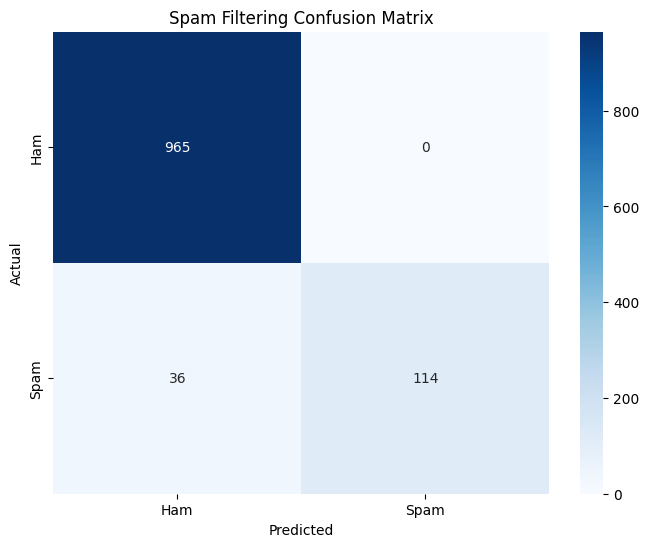

In [16]:


df = pd.read_csv("spam.csv", encoding='latin-1')


if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.rename(columns={"spamORham": "label", "Message": "text"}, inplace=True)
df["label"] = df["label"].map({"ham": 0, "spam": 1})


vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text']) 
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Filtering Confusion Matrix')
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.92      0.92      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



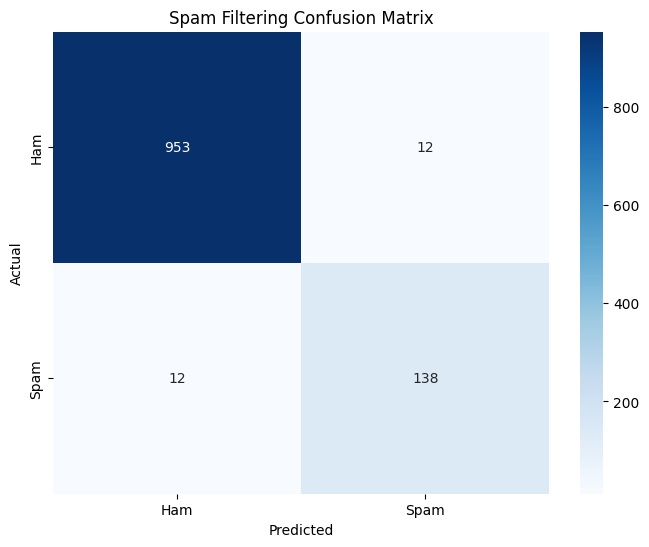

In [20]:


vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text']) 
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB(alpha=0.1) 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Filtering Confusion Matrix')
plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       965
           1       0.87      0.96      0.91       150

    accuracy                           0.98      1115
   macro avg       0.93      0.97      0.95      1115
weighted avg       0.98      0.98      0.98      1115



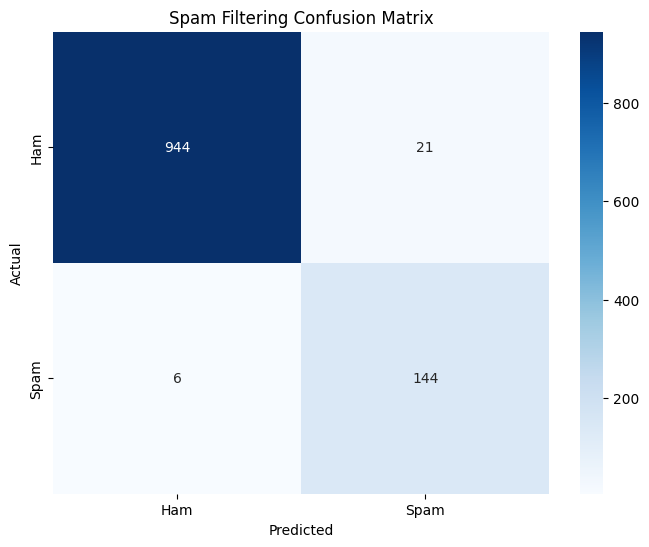

In [26]:


df = pd.read_csv("spam.csv", encoding='latin-1')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.rename(columns={"spamORham": "label", "Message": "text"}, inplace=True)
df["label"] = df["label"].map({"ham": 0, "spam": 1})


vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

X = vectorizer.fit_transform(df['text'])
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = MultinomialNB(alpha=0.1) 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Spam Filtering Confusion Matrix')
plt.show()

Final Classification Report (Threshold 0.7 & N-grams):

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       965
           1       0.97      0.93      0.95       150

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



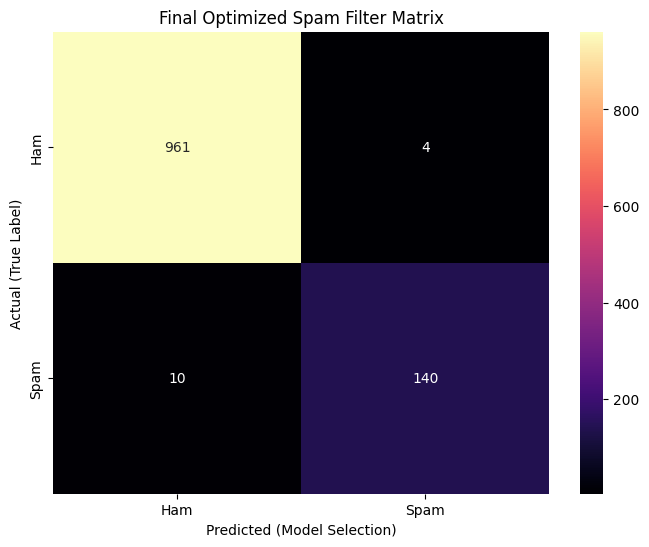

Test result for a sample message: Spam


In [ ]:




vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['text']) 
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)


y_probs = model.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs > 0.7).astype(int)


print("Final Classification Report (Threshold 0.7 & N-grams):\n")
print(classification_report(y_test, y_pred_final))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='magma', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted (Model Selection)')
plt.ylabel('Actual (True Label)')
plt.title('Final Optimized Spam Filter Matrix')
plt.show()

def check_spam(message):
    vec = vectorizer.transform([message])
    prob = model.predict_proba(vec)[:, 1]
    return "Spam" if prob > 0.7 else "Ham"

print(f"Test result for a sample message: {check_spam('Congratulations! You won a cash prize!')}")

In [22]:


accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Accuracy: {accuracy * 100:.2f}%")

Final Accuracy: 98.74%
